In [63]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\admin\Downloads\Retail and wherehouse Sale.csv")


In [3]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [4]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip().str.replace(" ","_").str.lower()
df.columns

Index(['year', 'month', 'supplier', 'item_code', 'item_description',
       'item_type', 'retail_sales', 'retail_transfers', 'warehouse_sales'],
      dtype='object')

In [6]:
df.isnull().sum()

year                 0
month                0
supplier            33
item_code            0
item_description     0
item_type            0
retail_sales         1
retail_transfers     0
warehouse_sales      0
dtype: int64

In [7]:
df['supplier'] = df['supplier'].fillna('Unknown')
df['retail_sales'] = df['retail_sales'].fillna(df['retail_sales'].median())

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.groupby("supplier")[["retail_sales","retail_transfers","warehouse_sales"]].sum()

,retail_sales,retail_transfers,warehouse_sales
supplier,,,
A I G WINE & SPIRITS,0.00,0.0,26.00
ADAMBA IMPORTS INTL,6.07,6.0,1.00
AIKO IMPORTERS INC,0.08,0.0,1.00
ALLAGASH BREWING COMPANY,61.65,62.0,847.00
ALLIED IMPORTERS USA LTD,0.00,1.0,1.00
...,...,...,...
WINERY EXCHANGE INC,0.08,0.0,22.00
YOUNG WON TRADING INC,507.32,509.0,842.95
YUENGLING BREWERY,2734.59,2670.0,14206.84


In [10]:
df.groupby("item_type")[["retail_sales","warehouse_sales"]].sum()

,retail_sales,warehouse_sales
item_type,,
BEER,59538.76,697279.68
DUNNAGE,0.00,-12115.00
KEGS,0.00,8400.00
LIQUOR,81742.85,8796.90
NON-ALCOHOL,6824.78,2438.42
REF,46.27,-1329.00
STR_SUPPLIES,345.60,0.00
WINE,59688.84,119459.93


In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import calendar
# This transform numbering of month into name into abberivaton/name
df["month"] = df['month'].apply(lambda x: calendar.month_abbr[x])

df.groupby("month")[["retail_sales","warehouse_sales"]].sum()

,retail_sales,warehouse_sales
month,,
Jan,74318.77,284114.72
Jul,94539.12,418094.42
Mar,34523.90,113305.22
Sep,4805.31,7416.57


In [14]:
top_supplier = df.groupby("supplier")[["retail_sales"]].sum().sort_values(by="retail_sales",ascending=False).head(10).reset_index()
top_supplier

,supplier,retail_sales
0,DIAGEO NORTH AMERICA INC,13840.54
1,E & J GALLO WINERY,12742.24
2,ANHEUSER BUSCH INC,10091.64
3,CONSTELLATION BRANDS,9931.78
4,JIM BEAM BRANDS CO,9845.79
5,CROWN IMPORTS,9341.80
6,SAZERAC CO,7739.14
7,MILLER BREWING COMPANY,7737.55
8,BACARDI USA INC,6121.70
9,HEAVEN HILL DISTILLERIES INC,6075.45


In [15]:
import matplotlib.pyplot as plt

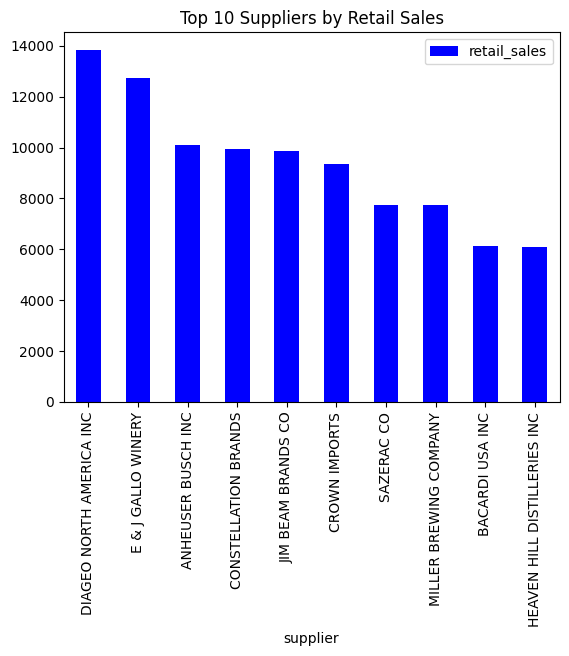

In [21]:
top_supplier.plot(kind='bar', x='supplier', y='retail_sales',color="Blue")
plt.title('Top 10 Suppliers by Retail Sales')
plt.show()

In [26]:
item_sales = df.groupby("item_type")[["retail_sales"]].sum()
item_sales

,retail_sales
item_type,
BEER,59538.76
DUNNAGE,0.00
KEGS,0.00
LIQUOR,81742.85
NON-ALCOHOL,6824.78
REF,46.27
STR_SUPPLIES,345.60
WINE,59688.84


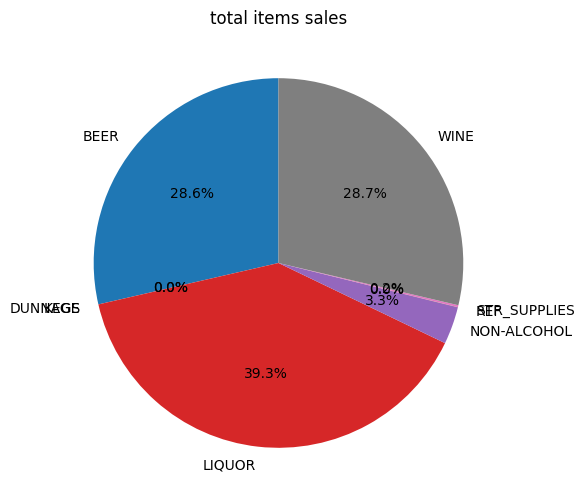

In [38]:
plt.figure(figsize=(12,6))
plt.pie(item_sales.squeeze(),labels = item_sales.index,autopct = "%1.1f%%",startangle=90)
plt.title('total items sales')
plt.show()

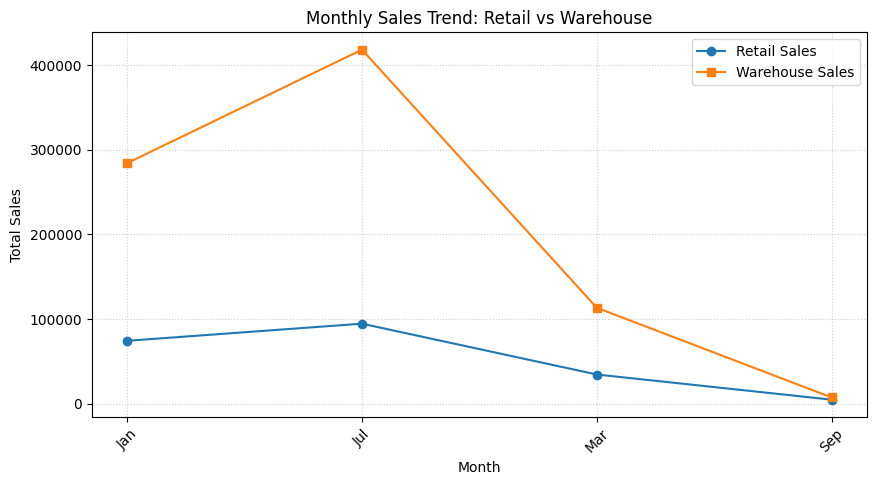

In [47]:
monthly = df.groupby('month')[["retail_sales","warehouse_sales"]].sum()
monthly
plt.figure(figsize=(10, 5))

# Plot the first line: index is X, retail_sales is Y
plt.plot(monthly.index, monthly['retail_sales'], marker='o', linestyle='-', label='Retail Sales')

# Plot the second line: index is X, warehouse_sales is Y
plt.plot(monthly.index, monthly['warehouse_sales'], marker='s', linestyle='-', label='Warehouse Sales')

plt.title('Monthly Sales Trend: Retail vs Warehouse')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend() # This adds the box identifying the lines
plt.grid(True, linestyle=':', alpha=0.6) # Optional: makes it easier to read
plt.show()

In [55]:
items_sales = df.groupby("item_description")[["retail_sales"]].sum().sort_values(by="retail_sales",ascending=False).head(10).reset_index()
items_sales

,item_description,retail_sales
0,ICE,3842.00
1,CORONA EXTRA LOOSE NR - 12OZ,2845.00
2,TITO'S HANDMADE VODKA - 1.75L,2330.99
3,HEINEKEN LOOSE NR - 12OZ,2096.00
4,STELLA ARTOIS LOOSE NR - 11.2OZ,1348.00
5,MILLER LITE HIGH GRAPHIC LOOSE NR - 12OZ,1258.00
6,CORONA EXTRA 2/12 NR - 12OZ,1105.00
7,MILLER LITE 30PK CAN - 12OZ,1045.00
8,YUENGLING LAGER LOOSE NR - 12OZ,961.00
9,BUD LIGHT 30PK CAN,958.00


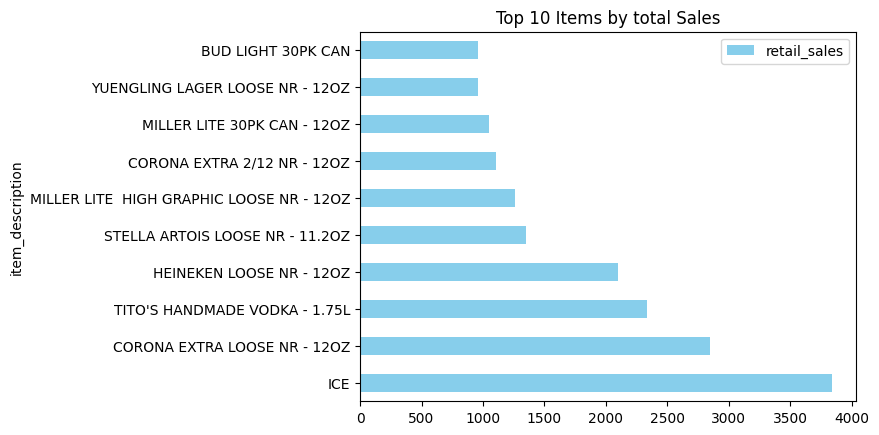

In [62]:
items_sales.plot(kind='barh', x='item_description', y='retail_sales',color="skyBlue")
plt.title("Top 10 Items by total Sales")
plt.show()